# Lab 3 – Image Manipulations using OpenCV
**ARTI 404 – Image Processing**

## Task 1: Geometric Transformations

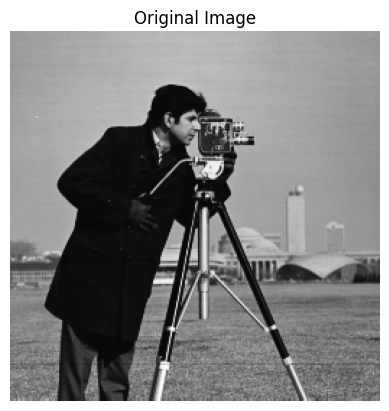

Original size: (256, 256, 3)


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('images/cameraman.tif')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()
print('Original size:', img.shape)

### 1. Increase the size of the image

Original size: (256, 256, 3)
Resized size: (512, 512, 3)


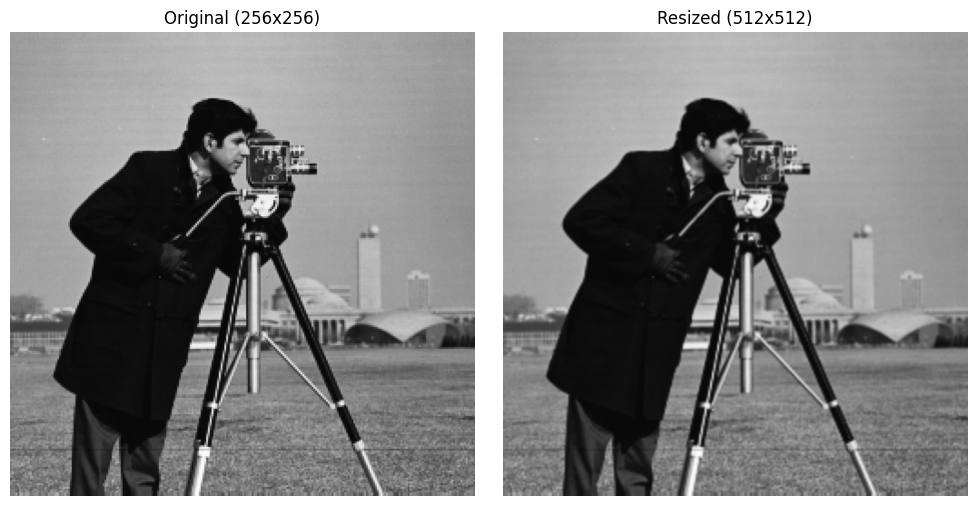

In [2]:
# Double the image size using cv2.resize
h, w = img.shape[:2]
resized = cv2.resize(img, (w * 2, h * 2), interpolation=cv2.INTER_LINEAR)

print('Original size:', img.shape)
print('Resized size:', resized.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original ({w}x{h})')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Resized ({w*2}x{h*2})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2. Rotate the image by 120 degrees

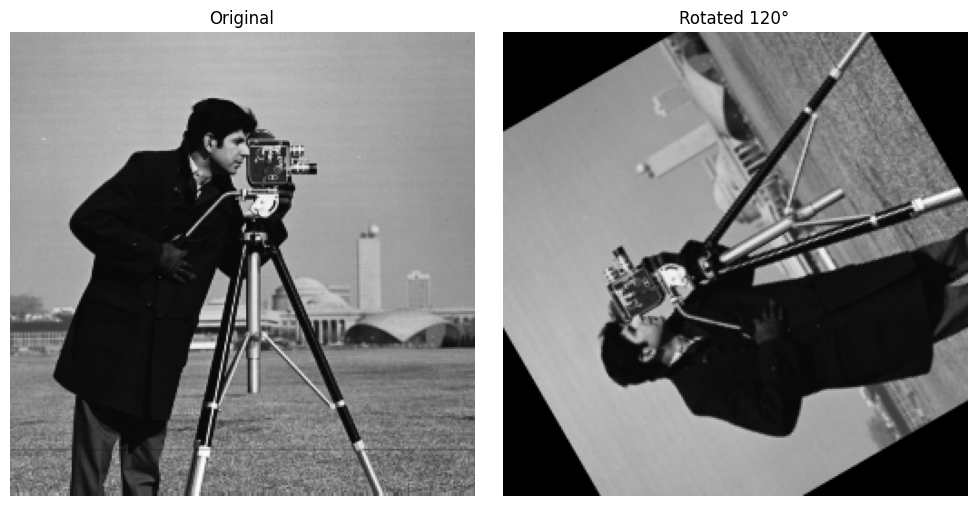

In [3]:
# Rotate 120 degrees around the center
h, w = img.shape[:2]
center = (w // 2, h // 2)
M_rotate = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(img, M_rotate, (w, h))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[1].set_title('Rotated 120°')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 3. Shear operation

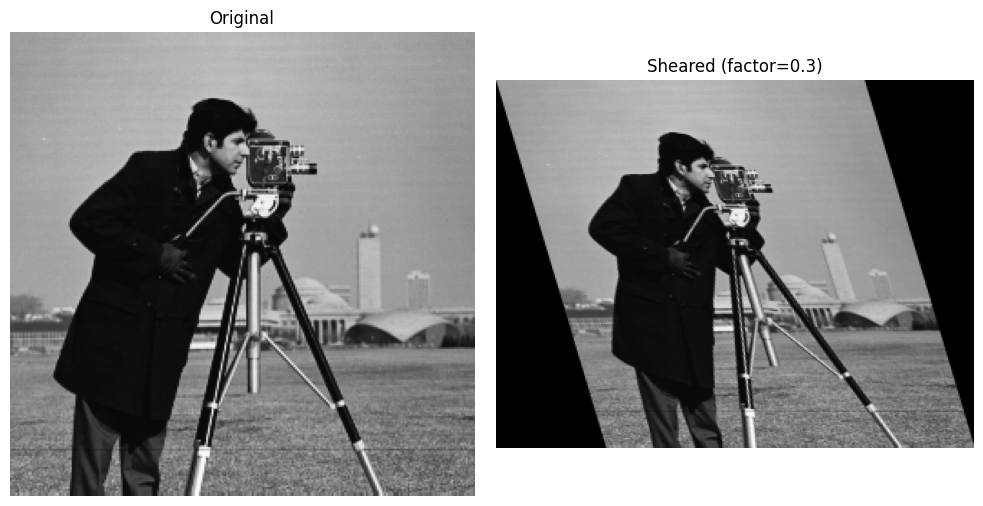

In [4]:
# Shear transformation using warpAffine
h, w = img.shape[:2]
shear_factor = 0.3

# Shear matrix: [[1, shear_x, 0], [0, 1, 0]]
M_shear = np.float32([[1, shear_factor, 0],
                       [0, 1, 0]])

sheared = cv2.warpAffine(img, M_shear, (int(w + h * shear_factor), h))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Sheared (factor={shear_factor})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Task 2: Intensity Transformations

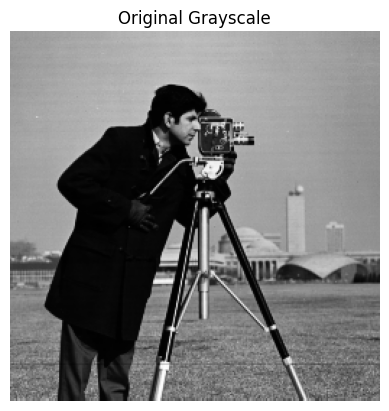

In [5]:
# Load image in grayscale for intensity transformations
gray = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')
plt.show()

### 1. Negative

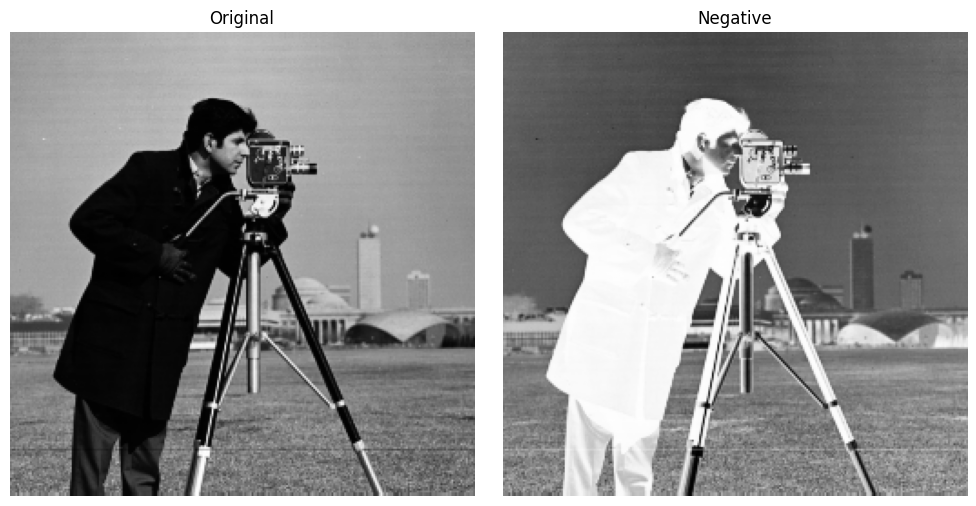

In [6]:
# Negative: s = 255 - r
negative = 255 - gray

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(negative, cmap='gray')
axes[1].set_title('Negative')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2. Log Transformation

Constant c = 46.03


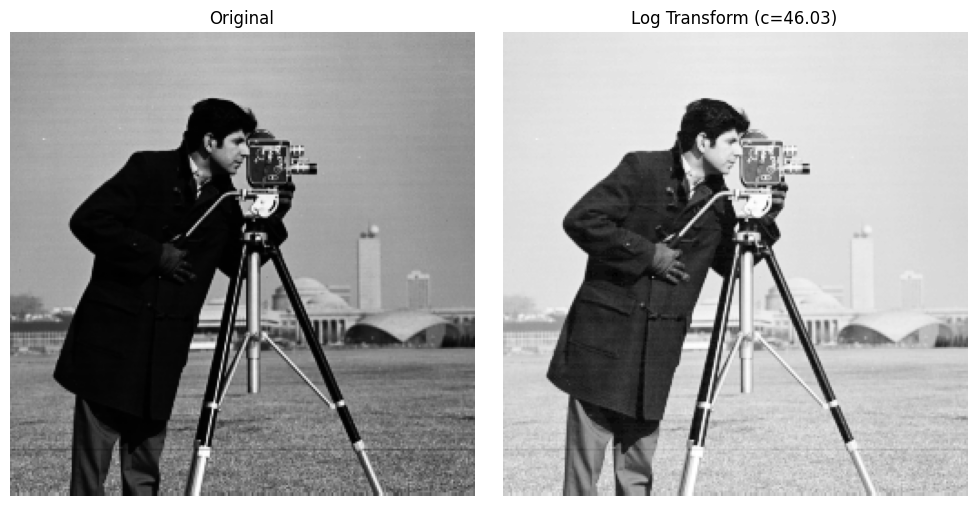

In [7]:
# Log: s = c * log(1 + r)
# c is chosen so that the max output maps to 255
c = 255 / np.log(1 + np.max(gray))
log_transformed = c * np.log(1 + gray.astype(np.float64))
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))

print(f'Constant c = {c:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(log_transformed, cmap='gray')
axes[1].set_title(f'Log Transform (c={c:.2f})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 3. Power Law (Gamma Correction)

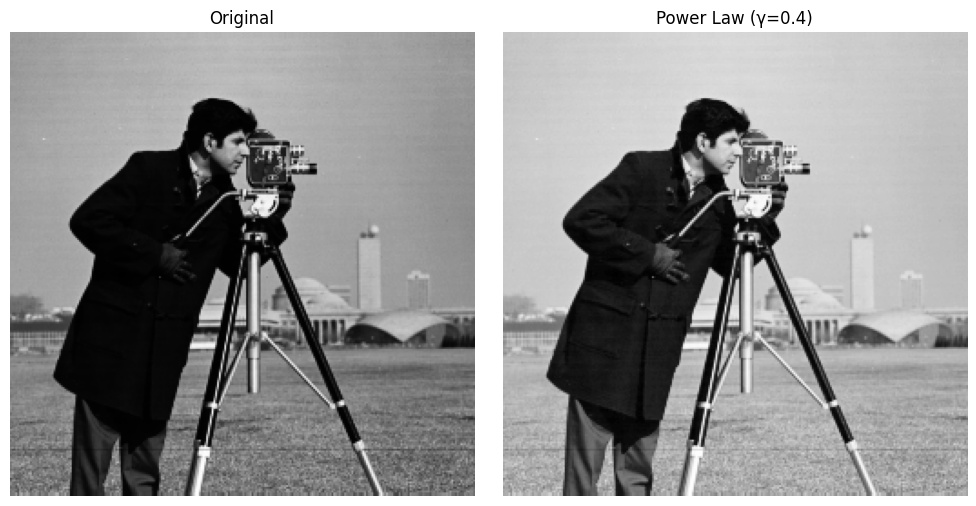

In [8]:
# Power law: s = c * r^gamma
# gamma < 1 brightens (increases contrast in dark regions)
gamma = 0.4
c = 1.0

# Normalize to [0,1], apply gamma, scale back to [0,255]
normalized = gray / 255.0
power_law = c * np.power(normalized, gamma)
power_law = np.uint8(np.clip(power_law * 255, 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(power_law, cmap='gray')
axes[1].set_title(f'Power Law (γ={gamma})')
axes[1].axis('off')
plt.tight_layout()
plt.show()